# Atelier Seaborn — Analyse exploratoire des données IoT

Ce notebook réalise une analyse exploratoire du dataset de capteurs IoT (température, humidité, pression, consommation, état) à l'aide de **Seaborn**, en s'appuyant sur NumPy, Pandas et Matplotlib.

## Étape 4 — Import des librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

EXPORT_DIR = "../exports"
import os
os.makedirs(EXPORT_DIR, exist_ok=True)


Étape 5 — Import du dataset dans df



In [2]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Étape 6 — Vérification du contenu du dataframe

In [3]:
print("Dimensions :", df.shape)
df.info()

Dimensions : (605, 9)
<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


In [4]:
df.describe(include="all")

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
count,605,605,605,605,599.000000,600.00000,600.000000,600.000000,601
unique,600,600,12,4,NaN,NaN,NaN,NaN,3
top,M0026,2026-01-06 01:00:00,C002,B001,NaN,NaN,NaN,NaN,OK
freq,2,2,52,153,NaN,NaN,NaN,NaN,567
mean,NaN,NaN,NaN,NaN,24.878314,64.92620,1012.221900,208.675417,NaN
std,NaN,NaN,NaN,NaN,4.059576,10.76905,10.599042,72.243567,NaN
min,NaN,NaN,NaN,NaN,-18.500000,28.52000,850.000000,18.120000,NaN
25%,NaN,NaN,NaN,NaN,22.570000,58.17250,1006.790000,160.177500,NaN
50%,NaN,NaN,NaN,NaN,24.860000,65.37500,1012.855000,206.150000,NaN
75%,NaN,NaN,NaN,NaN,27.275000,71.61500,1017.827500,254.127500,NaN


In [5]:
# Valeurs manquantes
df.isna().sum()

id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

**Constat :** le dataset contient 605 lignes et 9 colonnes. On observe quelques valeurs manquantes (température, humidité, pression, consommation, état) qu'il faudra garder à l'esprit pour la suite (Seaborn ignore les NaN par défaut dans la plupart des fonctions de distribution).

## Partie 1 — Distribution d'une variable avec `histplot()`

### 1) Distribution des températures

1.   Élément de liste
2.   Élément de liste



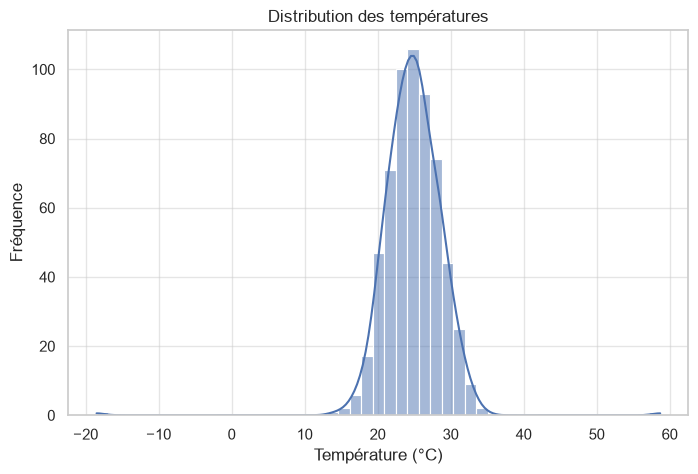

In [6]:
plt.figure()
sns.histplot(data=df, x="temperature", kde=True)
plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Fréquence")
plt.show()

In [7]:
print(df["temperature"].median(), df["temperature"].mean())

24.86 24.87831385642738


### 2) Autour de quelle valeur les températures sont concentrées ?

Les températures sont concentrées **autour de 24-25 °C** (médiane ≈ 24,86 °C, moyenne ≈ 24,88 °C), ce qui correspond au pic principal de l'histogramme.

### 3) La distribution semble-t-elle symétrique ?

Globalement **oui**, la distribution est assez symétrique et proche d'une loi normale autour de 25 °C, avec une légère traîne vers les valeurs basses et hautes due aux valeurs extrêmes.

### 4) Existe-t-il des valeurs extrêmes ?

**Oui.** On observe des valeurs très éloignées de la masse principale : un minimum proche de **-18,5 °C** et un maximum proche de **58,7 °C**, largement en dehors de la plage physiquement plausible pour une pièce/bâtiment — probablement des erreurs de capteur (à confirmer avec la colonne `etat`).

### 5) Modifier le nombre de classes (bins)

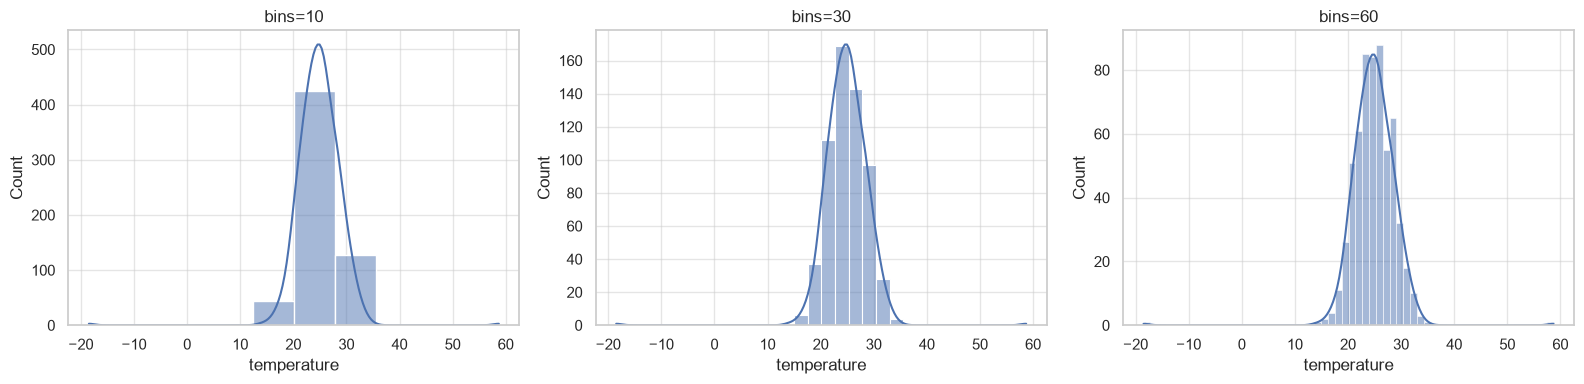

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, b in zip(axes, [10, 30, 60]):
    sns.histplot(data=df, x="temperature", bins=b, kde=True, ax=ax)
    ax.set_title(f"bins={b}")
plt.tight_layout()
plt.show()

Avec **peu de classes (10)**, la distribution paraît lisse mais on perd du détail. Avec **beaucoup de classes (60)**, on distingue mieux les valeurs extrêmes isolées mais le graphique devient plus 'bruité'. Un compromis autour de **30 classes** donne une lecture claire de la forme générale tout en distinguant les outliers.

### 6) Distribution des températures par bâtiment

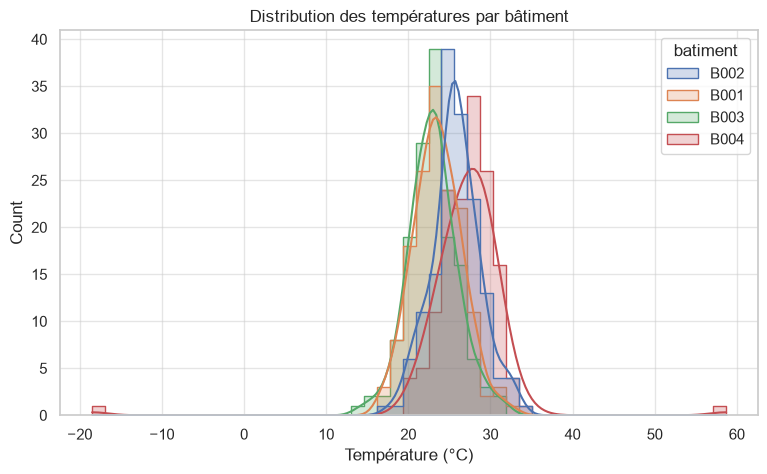

In [9]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="temperature", hue="batiment", kde=True, element="step")
plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

On voit que les bâtiments n'ont pas exactement la même distribution : **B004** semble avoir les températures les plus dispersées (et contient les valeurs les plus extrêmes), tandis que B001/B002/B003 sont plus resserrés autour de leur moyenne.

## Partie 2 — Distribution d'une variable avec `kdeplot()`

### 1) Distribution des températures

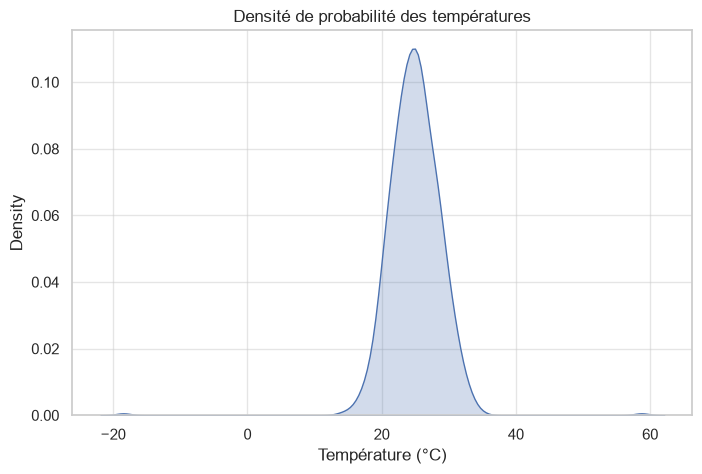

In [10]:
plt.figure()
sns.kdeplot(data=df, x="temperature", fill=True)
plt.title("Densité de probabilité des températures")
plt.xlabel("Température (°C)")
plt.show()

### 2) Distribution des températures par bâtiment

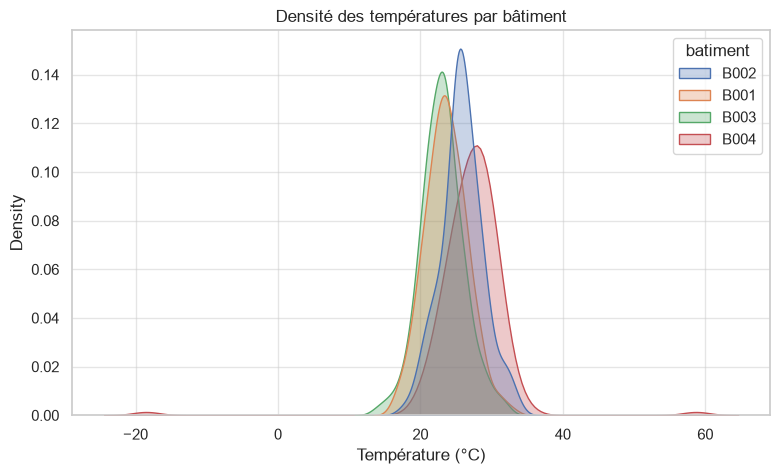

In [11]:
plt.figure(figsize=(9,5))
sns.kdeplot(data=df, x="temperature", hue="batiment", fill=True, common_norm=False, alpha=0.3)
plt.title("Densité des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.show()

Le `kdeplot()` confirme visuellement ce que montrait l'histogramme, mais en lissant les fluctuations : la courbe de **B004** est plus large et plus aplatie (plus grande variance), signe d'une plus grande dispersion des mesures que les autres bâtiments.

## Partie 3 — Distribution d'une variable avec `boxplot()`

### 1) Distribution des températures

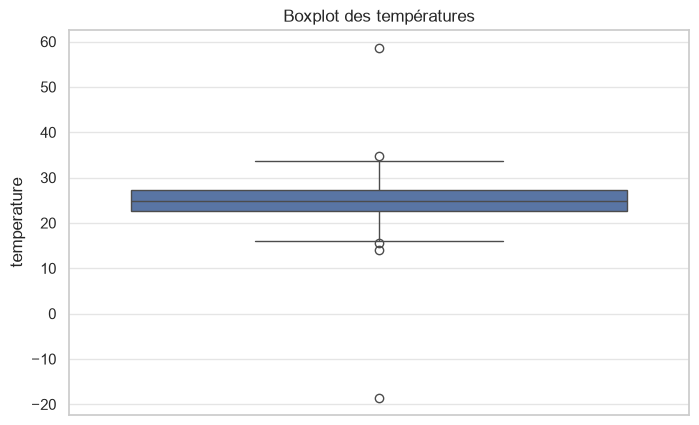

In [12]:
plt.figure()
sns.boxplot(data=df, y="temperature")
plt.title("Boxplot des températures")
plt.show()

### 2) Distribution des températures par bâtiment

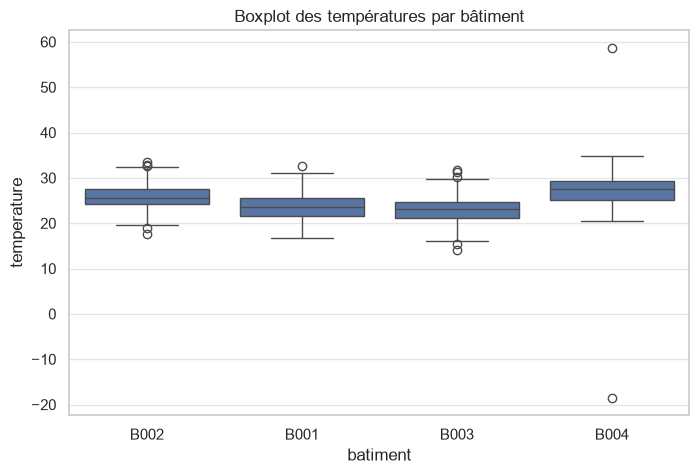

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="batiment", y="temperature")
plt.title("Boxplot des températures par bâtiment")
plt.show()

### 3) Statistiques par bâtiment (médiane, dispersion, valeurs extrêmes)

In [14]:
stats = df.groupby("batiment")["temperature"].agg(
    mediane="median",
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
    minimum="min",
    maximum="max",
)
stats["IQR"] = stats["q3"] - stats["q1"]
stats

,mediane,q1,q3,minimum,maximum,IQR
batiment,,,,,,
B001,23.540,21.6100,25.6700,16.77,32.72,4.0600
B002,25.670,24.2675,27.5300,17.67,33.60,3.2625
B003,23.045,21.0825,24.5950,14.11,31.74,3.5125
B004,27.535,25.1750,29.2825,-18.50,58.70,4.1075


**a) Médiane par bâtiment :** B001 ≈ 23,54 °C · B002 ≈ 25,67 °C · B003 ≈ 23,05 °C · B004 ≈ 27,54 °C.

**b) Dispersion (IQR) :** B001 ≈ 4,06 · B002 ≈ 3,26 · B003 ≈ 3,51 · **B004 ≈ 4,11 (la plus grande)**, en cohérence avec un écart-type nettement plus élevé pour B004 (≈ 5,4 contre ≈ 3 pour les autres).

**c) Valeurs extrêmes :** chaque bâtiment présente quelques points hors moustaches, mais **B004 concentre les valeurs les plus extrêmes** (jusqu'à -18,5 °C et 58,7 °C), très éloignées des autres bâtiments.

### 4) Quels bâtiments ont les valeurs les plus extrêmes ?

**B004** est clairement le bâtiment avec les valeurs les plus extrêmes (amplitude et dispersion les plus importantes), suivi de B002 et B003 qui comptent aussi quelques outliers modérés.

## Partie 4 — Distribution d'une variable avec `violinplot()`

### 1) Distribution des températures

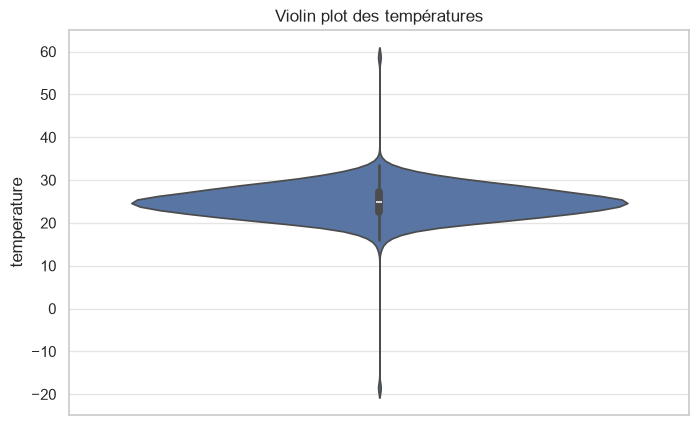

In [15]:
plt.figure()
sns.violinplot(data=df, y="temperature")
plt.title("Violin plot des températures")
plt.show()

### 2) Distribution des températures par bâtiment

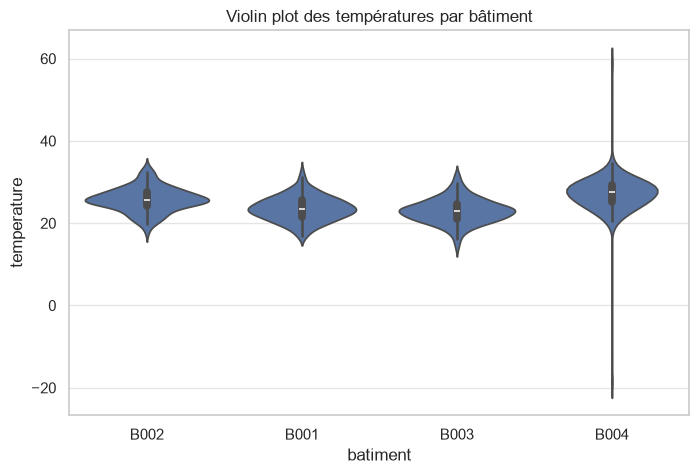

In [16]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="batiment", y="temperature")
plt.title("Violin plot des températures par bâtiment")
plt.show()

### 3) Informations supplémentaires par rapport au boxplot

Le `violinplot()` combine un boxplot avec une estimation de densité (KDE). Il montre donc, en plus de la médiane et des quartiles, la **forme complète de la distribution** (multimodalité, asymétrie, zones de forte/faible densité) : on distingue par exemple si les valeurs sont concentrées en un seul pic ou réparties sur plusieurs modes, ce qu'un simple boxplot ne permet pas de voir.

## Partie 5 — Comptage des catégories avec `countplot()`

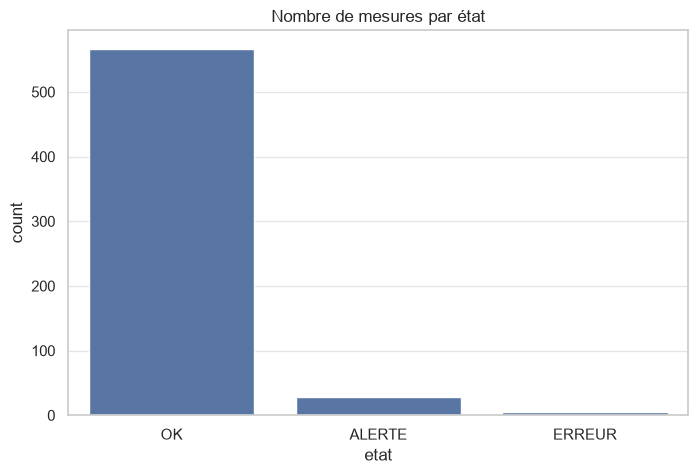

etat
OK        567
ALERTE     29
ERREUR      5
Name: count, dtype: int64

In [17]:
plt.figure()
sns.countplot(data=df, x="etat", order=df["etat"].value_counts().index)
plt.title("Nombre de mesures par état")
plt.show()

df["etat"].value_counts()

### 2) Nombre de mesures par bâtiment

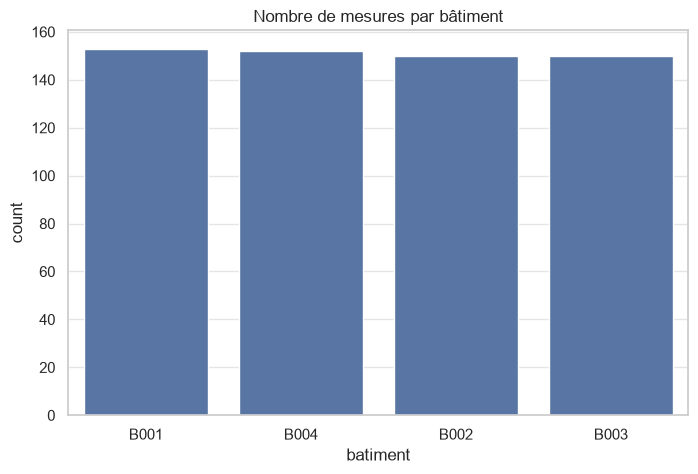

batiment
B001    153
B004    152
B002    150
B003    150
Name: count, dtype: int64

In [18]:
plt.figure()
sns.countplot(data=df, x="batiment", order=df["batiment"].value_counts().index)
plt.title("Nombre de mesures par bâtiment")
plt.show()

df["batiment"].value_counts()

### 3) États des capteurs par bâtiment

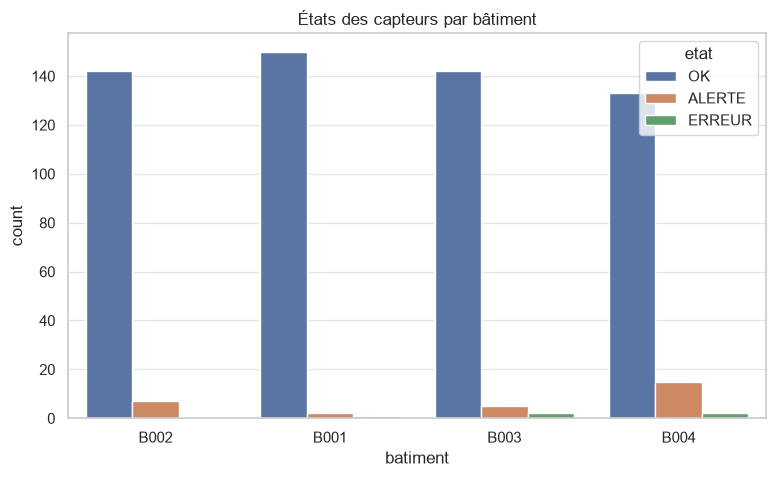

etat,ALERTE,ERREUR,OK
batiment,,,
B001,2,1,150
B002,7,0,142
B003,5,2,142
B004,15,2,133


In [19]:
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="batiment", hue="etat")
plt.title("États des capteurs par bâtiment")
plt.show()

pd.crosstab(df["batiment"], df["etat"])

**a) Bâtiment avec le plus de mesures OK :** **B001** (150 mesures OK).

**b) Bâtiment avec le plus de mesures ALERTE :** **B004** (15 alertes), très nettement devant les autres.

**c) Bâtiment avec le plus de mesures ERREUR :** **B003 et B004** sont ex-æquo (2 erreurs chacun) ; B001 en compte 1 et B002 aucune.

Ces résultats confirment que **B004 est le bâtiment le plus problématique** : c'est aussi celui qui affichait les températures les plus extrêmes et dispersées.

## Partie 6 — Relation entre deux variables avec `scatterplot()`

### 1) Relation température / consommation

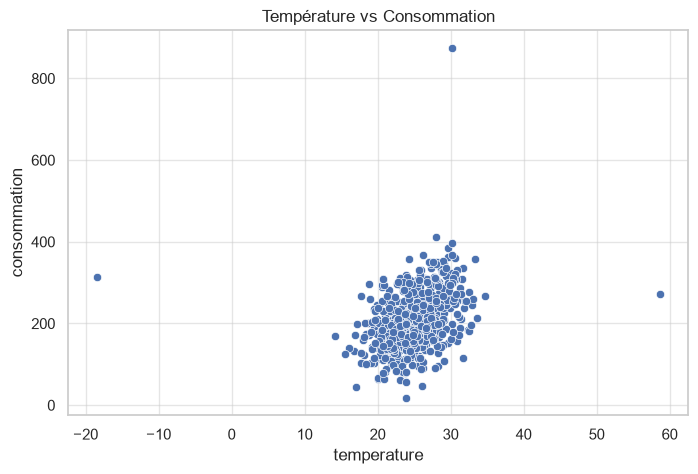

In [20]:
plt.figure()
sns.scatterplot(data=df, x="temperature", y="consommation")
plt.title("Température vs Consommation")
plt.show()

### 2) Relation température / consommation par bâtiment

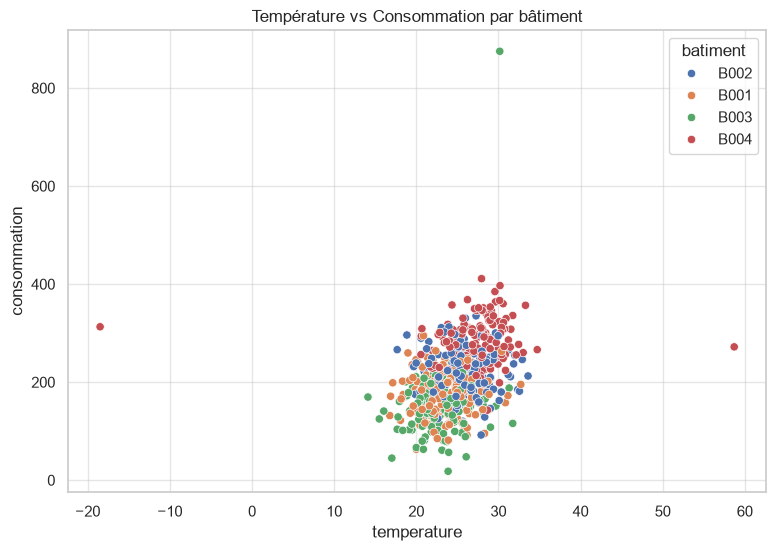

In [21]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment")
plt.title("Température vs Consommation par bâtiment")
plt.show()

### 3) Modifier la taille des points

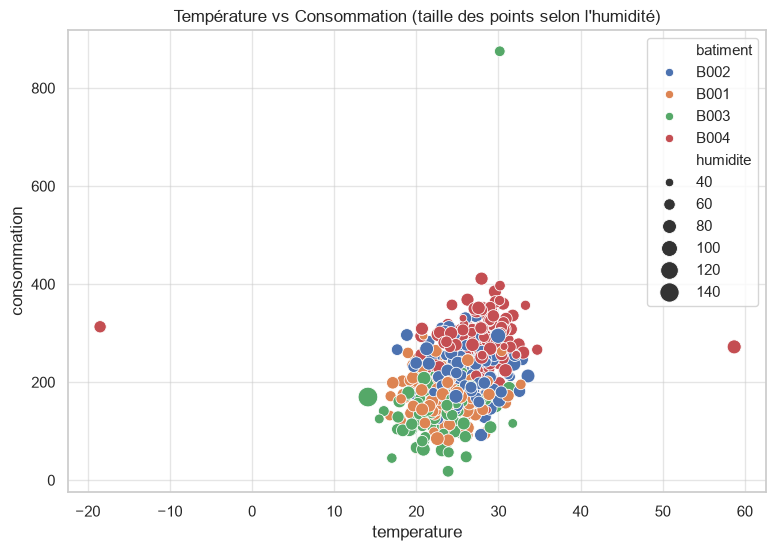

In [22]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="temperature", y="consommation", hue="batiment", size="humidite", sizes=(20, 200))
plt.title("Température vs Consommation (taille des points selon l'humidité)")
plt.show()

On observe une **tendance positive modérée** entre température et consommation (coefficient de corrélation ≈ 0,32, cf. Partie 9) : plus il fait chaud, plus la consommation énergétique a tendance à augmenter, sans que la relation soit très forte ni identique dans tous les bâtiments.

## Partie 7 — Régression avec `regplot()`

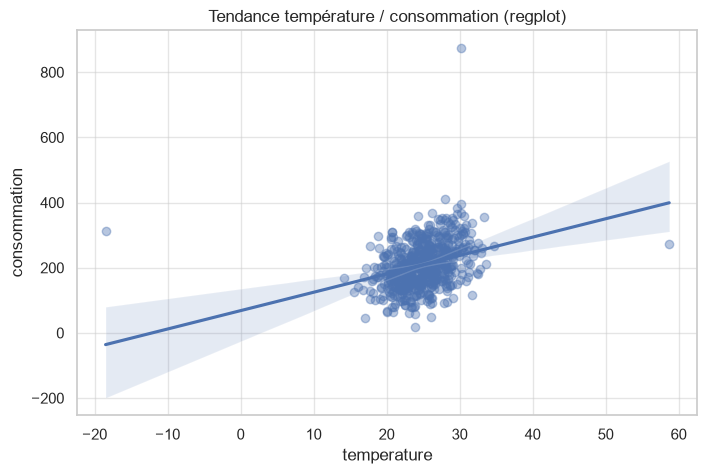

In [23]:
plt.figure()
sns.regplot(data=df, x="temperature", y="consommation", scatter_kws={"alpha":0.4})
plt.title("Tendance température / consommation (regplot)")
plt.show()

La droite de régression confirme une **pente positive** : la consommation énergétique tend à augmenter avec la température, ce qui est cohérent avec un usage accru de la climatisation lors des pics de chaleur.

## Partie 8 — Régression avec `lmplot()`

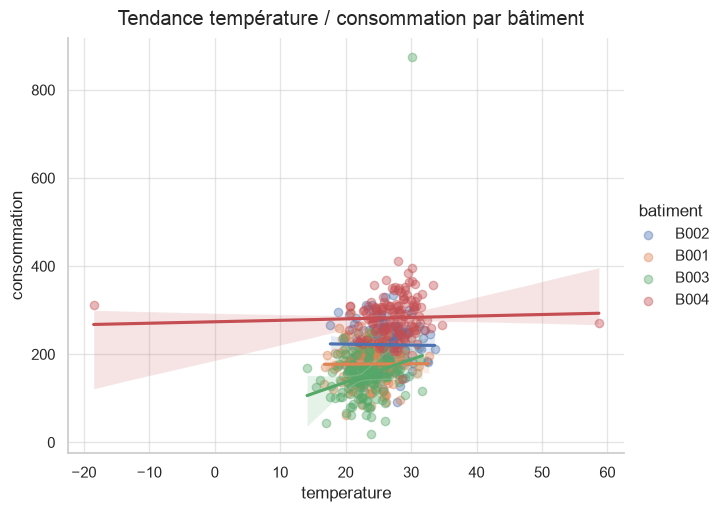

In [24]:
g = sns.lmplot(data=df, x="temperature", y="consommation", hue="batiment",
                height=5, aspect=1.3, scatter_kws={"alpha":0.4})
g.fig.suptitle("Tendance température / consommation par bâtiment", y=1.02)
plt.show()

La tendance positive se retrouve dans **chaque bâtiment pris séparément**, mais avec des pentes différentes : certains bâtiments (comme B004) semblent plus sensibles à la température que d'autres, suggérant des équipements ou une isolation différents selon le site.

## Partie 9 — Corrélations

### 1) Calcul des corrélations avec Pandas

In [25]:
corr = df[["temperature", "humidite", "pression", "consommation"]].corr()
corr

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


### 2) Matrice de corrélation

In [26]:
corr.round(2)

,temperature,humidite,pression,consommation
temperature,1.00,-0.01,0.06,0.32
humidite,-0.01,1.00,0.05,-0.05
pression,0.06,0.05,1.00,0.06
consommation,0.32,-0.05,0.06,1.00


### 3) Heatmap de corrélation

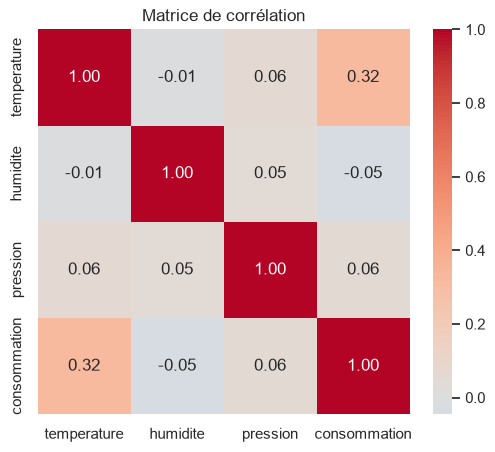

In [27]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

**a) Corrélations positives :** température ↔ consommation (≈ 0,32) est la plus marquée ; les autres paires sont très faiblement positives.

**b) Corrélations négatives :** humidité ↔ consommation (≈ -0,05) et température ↔ humidité (≈ -0,01) sont légèrement négatives mais quasi nulles.

**c) Corrélations proches de zéro :** pression est quasiment indépendante des autres variables (toutes les corrélations avec pression sont < 0,07 en valeur absolue).

**d) Variables les plus fortement liées :** **température et consommation** sont les deux variables les plus liées du dataset, même si la corrélation reste modérée (≈ 0,32) — aucune paire ne présente de lien très fort.